# Phase 4: Dimensionality Reduction

This notebook compresses the preprocessed gene expression matrix into a representation that is easier to cluster and visualize.

Why this stage matters:
- the original feature space is still very large after preprocessing,
- PCA captures the strongest global variance patterns,
- UMAP turns those compressed features into a 2D map for interpretation,
- and saving the fitted reducers allows the same transformations to be reused later in prediction and deployment.

The code below reuses the pipeline modules from `src/` so the notebook remains a transparent walkthrough rather than a separate implementation.

---

## Cell 1: Import reusable dimensionality-reduction tools

This cell prepares the notebook and imports the functions needed for PCA and UMAP.

What it sets up:
- project-root imports from `src/`,
- the preprocessing entry point so the notebook can rebuild the clean matrix if needed,
- the dimensionality-reduction entry point so PCA and UMAP run through the shared source module,
- and NumPy and plotting utilities for result inspection.

This keeps notebook logic aligned with the production pipeline instead of duplicating model code in place.

In [1]:
import os
import sys
import importlib
sys.path.append('..')
import numpy as np
import src.preprocessor as preprocessor
import src.dimensionality as dimensionality
importlib.reload(preprocessor)
importlib.reload(dimensionality)
run_preprocessing = preprocessor.run_preprocessing
run_dimensionality_reduction = dimensionality.run_dimensionality_reduction

print(f"Current working directory: {os.getcwd()}")
print(f"Using preprocessor module: {preprocessor.__file__}")
print(f"Using dimensionality module: {dimensionality.__file__}")

Current working directory: c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\notebook
Using preprocessor module: c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\notebook\..\src\preprocessor.py
Using dimensionality module: c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\notebook\..\src\dimensionality.py


## Cell 2: Recreate the scaled input matrix

This cell reruns preprocessing to generate `X_scaled`, which is the input to PCA.

This is useful because:
- it keeps the notebook self-contained,
- it guarantees dimensionality reduction is applied to the latest preprocessing logic,
- and it avoids hidden dependencies on variables from earlier notebook sessions.

Even though this repeats work, it improves reproducibility because the notebook can be executed from a clean kernel.

In [2]:
X_scaled, scaler, gene_names, cell_names, metadata = run_preprocessing('../config.yaml')


STARTING PREPROCESSING PIPELINE
Loading raw data...
  Expression loaded: 4645 genes x 23686 cells
  Metadata loaded:   (4645, 3)
Separating metadata from expression data...
  Metadata rows: 3
  Gene rows: 4642

Transposed shape: (23686, 4642) (cells x genes)
No missing values found ✓
Filtering low-variance genes (removing bottom 20%)...
  Before: 4642 genes
  After:  3713 genes
  Removed: 929 genes
Keeping top 5000 most variable genes...
  Final gene count: 3713
Applying log1p transformation...
  Log transformation complete ✓
Standardizing data (mean=0, std=1)...
  Mean: 0.0000 (should be ~0)
  Std:  1.0000 (should be ~1)

Processed data saved to c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\data\processed\expression_clean.csv

PREPROCESSING COMPLETE
Final shape: (23686, 3713) (cells x genes)


## Cell 3: Run PCA and UMAP through the shared pipeline

This is the main modeling step of the notebook.

Inside `run_dimensionality_reduction(...)`:
- PCA reduces the scaled gene matrix to a smaller set of principal components,
- the code reports how much variance those components explain,
- UMAP then projects the PCA representation into two dimensions,
- and the module saves both numerical outputs and visual artifacts.

Why PCA comes before UMAP:
- PCA denoises and compresses the data,
- reduces computation cost,
- and often improves the stability of neighborhood-based embedding methods.

STARTING DIMENSIONALITY REDUCTION
Running PCA: 3713 genes → 50 components...
  Variance explained by 50 PCs: 49.4%
  Shape after PCA: (23686, 50)


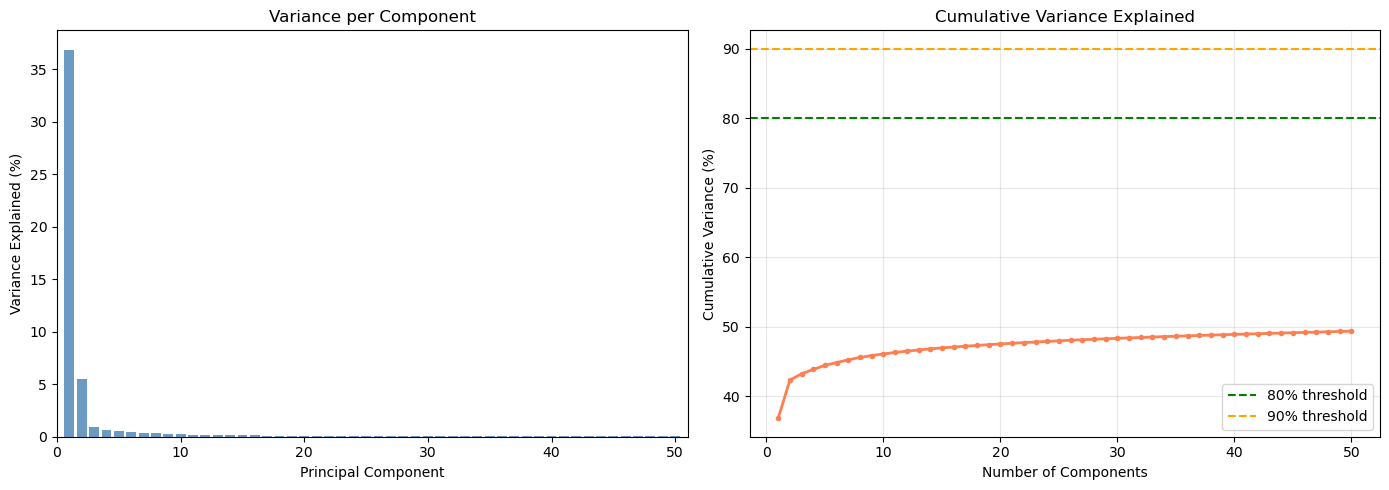

PCA variance plot saved!
Running UMAP: 50 components → 2D...
  (This may take 2-5 minutes for 4645 cells — please wait)
UMAP(n_jobs=1, random_state=42, verbose=True)
Mon May 11 19:11:26 2026 Construct fuzzy simplicial set
Mon May 11 19:11:26 2026 Finding Nearest Neighbors


c:\Users\DELL\miniconda3\envs\genomics_pipeline\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon May 11 19:11:26 2026 Building RP forest with 13 trees
Mon May 11 19:11:38 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Mon May 11 19:11:55 2026 Finished Nearest Neighbor Search
Mon May 11 19:12:02 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon May 11 19:12:28 2026 Finished embedding
  UMAP complete! Shape: (23686, 2)


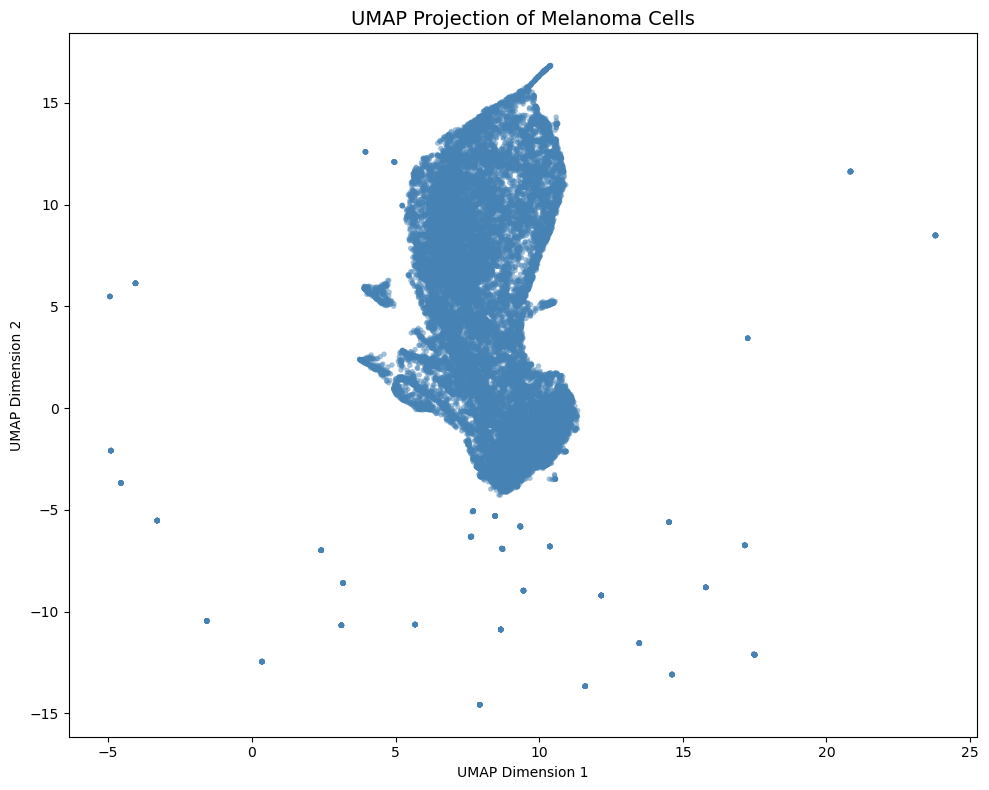

Basic UMAP plot saved!
Coordinates saved to results/

DIMENSIONALITY REDUCTION COMPLETE


In [3]:
X_pca, X_umap, pca, reducer = run_dimensionality_reduction(X_scaled, '../config.yaml')

## Cell 4: Inspect the shapes and saved outputs

This cell explains what the new arrays represent.

Interpretation:
- `X_pca` is still the modeling space and is used for clustering and classification,
- `X_umap` is mainly for visualization and exploratory interpretation,
- the number of rows should match the number of cells,
- and the reduced number of columns confirms that feature compression happened successfully.

This distinction is important because UMAP is visually useful, but PCA output is usually the more stable space for clustering and classification in this project.

In [4]:
print("Outputs:")
print(f"  X_pca shape:  {X_pca.shape}   (cells x 50 PCs)")
print(f"  X_umap shape: {X_umap.shape}  (cells x 2 UMAP dims)")


Outputs:
  X_pca shape:  (23686, 50)   (cells x 50 PCs)
  X_umap shape: (23686, 2)  (cells x 2 UMAP dims)


## Cell 5: Save the fitted PCA model

This cell stores the fitted PCA transformer using `joblib` and verifies it can be loaded back.

Why this matters:
- the predictor and API need the exact same PCA basis used during training,
- principal components learned on the training data must not be recomputed for every new sample,
- and serialization allows the transformation pipeline to be reproduced outside the notebook.

Saving the transformer is what makes the reduction stage portable across training, analysis, and deployment.

In [5]:
import joblib
pca_path = '../models/pca.pkl'
joblib.dump(pca, pca_path)

# Verify by loading back
pca_loaded = joblib.load(pca_path)

print('pca.pkl saved and verified!')
print(f'\nFile location: {pca_path}')
print(f'File size:     {os.path.getsize(pca_path) / 1024:.1f} KB')
print(f'\nPCA details:')
print(f'  Type:                  {type(pca)}')
print(f'  n_components:          {pca.n_components_}')
print(f'  n_features (genes):    {pca.n_features_in_}')
print(f'  Variance explained:    {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  PC1 explains:          {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2 explains:          {pca.explained_variance_ratio_[1]*100:.1f}%')
print()
print('WHY this is critical:')
print('  Phase 7 predict_new_patient() loads this file')
print('  New patient data MUST be compressed with this')
print('  exact PCA transformation (same components)')
print('  If missing → Phase 7 Cell 3 will throw FileNotFoundError')

pca.pkl saved and verified!

File location: ../models/pca.pkl
File size:     1481.5 KB

PCA details:
  Type:                  <class 'sklearn.decomposition._pca.PCA'>
  n_components:          50
  n_features (genes):    3713
  Variance explained:    49.4%
  PC1 explains:          36.8%
  PC2 explains:          5.5%

WHY this is critical:
  Phase 7 predict_new_patient() loads this file
  New patient data MUST be compressed with this
  exact PCA transformation (same components)
  If missing → Phase 7 Cell 3 will throw FileNotFoundError
